<a href="https://colab.research.google.com/github/NuriaGarciaV/ia_p26/blob/main/Copy_of_03_tarea_optimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

**Variables de decision:**

$$x = [x_0, x_1, x_2, x_3, x_4, x_5]^T \text{ donde } x_i \text{ son los kg del ingrediente } i$$

**Funcion objetivo:**

$$\min Z = 4.5x_0 + 9.0x_1 + 2.5x_2 + 3.0x_3 + 15.0x_4 + 3.5x_5$$

**Restricciones:**

$$\begin{aligned}
& 3.3x_0 + 3.2x_1 + 2.0x_2 + 2.8x_3 + 0.0x_4 + 2.5x_5 \geq 25 && \text{(Energía)} \\
& 90x_0 + 440x_1 + 80x_2 + 40x_3 + 0x_4 + 150x_5 \geq 1000 && \text{(Proteína)} \\
& 0.3x_0 + 2.7x_1 + 4.0x_2 + 8.0x_3 + 200.0x_4 + 1.5x_5 \geq 30 && \text{(Calcio)} \\
& 2.8x_0 + 6.5x_1 + 2.0x_2 + 0.8x_3 + 80.0x_4 + 12.0x_5 \geq 20 && \text{(Fósforo)} \\
& 8 \leq \sum x_i \leq 12 && \text{(Consumo total)} \\
& 0 \leq x_i \leq \text{Max}_i && \forall i
\end{aligned}$$

### 1.2 Eleccion de optimizador

**Optimizador elegido:**

`scipy.optimize.linprog` (con el método 'highs')

**Justificacion (2-3 oraciones):**

Este es un problema de Programación Lineal (LP), ya que tanto la función de costo como todas las restricciones (nutrientes, consumo total y límites de inclusión) son funciones lineales de las variables de decisión. El método 'highs' es el solver estándar más robusto de SciPy para este tipo de problemas, garantizando encontrar el óptimo global de manera eficiente y manejando correctamente las restricciones de desigualdad.

In [ ]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [ ]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    return np.dot(x, costos_p1)


def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    nutrientes_totales = np.dot(nutrientes_p1, x)
    intake_total = np.sum(x)

    # 1. Restricción de nutrientes (>= requerimientos mínimos)
    cumple_nutrientes = np.all(nutrientes_totales >= req_min_p1 - 1e-6)

    # 2. Restricción de consumo total (8 <= sum(x) <= 12)
    cumple_intake = (intake_total >= intake_min_p1 - 1e-6) and (intake_total <= intake_max_p1 + 1e-6)

    # 3. Restricción de límites individuales (0 <= x <= max)
    cumple_maximos = np.all(x >= -1e-6) and np.all(x <= max_kg_p1 + 1e-6)

    factible = cumple_nutrientes and cumple_intake and cumple_maximos

    return {
        'factible': factible,
        'nutrientes_totales': nutrientes_totales,
        'intake_total': intake_total
    }


def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    from scipy.optimize import linprog

    # Coeficientes de la función objetivo (costos)
    c = costos_p1

    # Restricciones de desigualdad (A_ub * x <= b_ub)
    # Para nutrientes (>=), multiplicamos por -1
    A_nutri = -nutrientes_p1
    b_nutri = -req_min_p1

    # Para intake (suma de x):
    # sum(x) <= 12
    # -sum(x) <= -8
    A_intake = np.array([
        np.ones(6),  # sum(x)
        -np.ones(6)  # -sum(x)
    ])
    b_intake = np.array([intake_max_p1, -intake_min_p1])

    # Consolidar todas las desigualdades
    A_final = np.vstack([A_nutri, A_intake])
    b_final = np.concatenate([b_nutri, b_intake])

    # Límites para cada x_i (0 <= x_i <= max_kg)
    bounds = [(0, m) for m in max_kg_p1]

    res = linprog(c, A_ub=A_final, b_ub=b_final, bounds=bounds, method='highs')

    if res.success:
        return res.x, res.fun
    else:
        return None, None

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


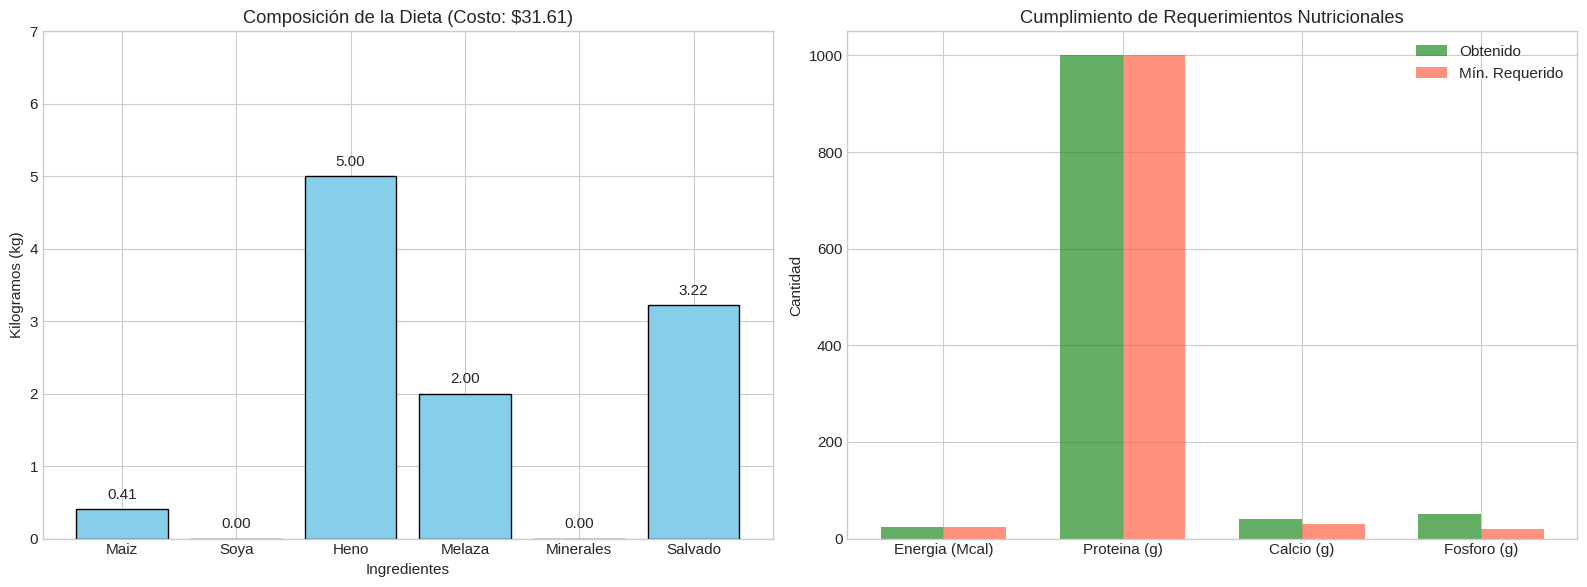

In [ ]:
import matplotlib.pyplot as plt

# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    # 1. Obtener nutrientes obtenidos de la solución
    nutrientes_obtenidos = np.dot(nutrientes_p1, x_opt)

    # Crear la figura con dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: Cantidad de cada ingrediente
    bars1 = ax1.bar(nombres_p1, x_opt, color='skyblue', edgecolor='black')
    ax1.set_title(f"Composición de la Dieta (Costo: ${costo_opt:.2f})")
    ax1.set_ylabel("Kilogramos (kg)")
    ax1.set_xlabel("Ingredientes")
    ax1.set_ylim(0, max(max_kg_p1) + 1)

    # Añadir etiquetas de valor sobre las barras
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom')

    # Panel 2: Comparativa de Nutrientes (Obtenido vs Requerido)
    x = np.arange(len(nombres_nutrientes_p1))
    width = 0.35

    ax2.bar(x - width/2, nutrientes_obtenidos, width, label='Obtenido', color='forestgreen', alpha=0.7)
    ax2.bar(x + width/2, req_min_p1, width, label='Mín. Requerido', color='tomato', alpha=0.7)

    ax2.set_title("Cumplimiento de Requerimientos Nutricionales")
    ax2.set_xticks(x)
    ax2.set_xticklabels(nombres_nutrientes_p1)
    ax2.set_ylabel("Cantidad")
    ax2.legend()

    # Ajustar diseño y mostrar
    plt.tight_layout()
    plt.show()


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
if x_opt_p1 is not None:
    for nombre, kg in zip(nombres_p1, x_opt_p1):
        print(f"  {nombre}: {kg:.3f} kg")
    print(f"Costo total: ${costo_opt_p1:.2f}")
    print(f"Intake total: {info_p1['intake_total']:.2f} kg")
    print(f"Factible: {info_p1['factible']}")

    plot_p1(x_opt_p1, costo_opt_p1)
else:
    print("No se encontró una solución factible.")

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

**Variables de decision:**

$$x = [x_1, x_2, x_3, x_4, x_5]^T \text{ donde } x_i \text{ es la proporción de capital invertida en el activo } i.$$

**Funcion objetivo:**

$$\min \sigma_p^2 = x^T \Sigma x$$
*(Donde $\Sigma$ representa la matriz de covarianza de los activos).*

**Restricciones:**

$$\begin{aligned}
& \sum_{i=1}^{5} r_i x_i \geq 0.08 && \text{(Rendimiento mínimo)} \\
& \sum_{i=1}^{5} x_i = 1 && \text{(Capital total)} \\
& 0 \leq x_i \leq 0.40 && \forall i \in \{1, \dots, 5\}
\end{aligned}$$

### 2.2 Eleccion de optimizador

**Optimizador elegido:**

`scipy.optimize.minimize` (Método SLSQP)

**Justificacion (2-3 oraciones):**

Este es un problema de Programación Cuadrática (QP) porque la función objetivo (varianza) es una forma cuadrática y las restricciones son lineales. Se utiliza el algoritmo SLSQP (Sequential Least SQuares Programming) ya que es el solver de SciPy diseñado para optimizar funciones no lineales con restricciones de igualdad, desigualdad y límites de caja (bounds).

In [ ]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [ ]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    # La varianza de un portafolio se calcula como w^T * Cov * w
    return w.T @ cov_p2 @ w


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
            'factible': bool
            'rendimiento': float -- rendimiento esperado del portafolio
            'varianza': float
            'suma_pesos': float
    """
    rendimiento = np.dot(w, rendimientos_p2)
    varianza = objetivo_p2(w)
    suma_pesos = np.sum(w)

    # Verificación de restricciones con pequeñas tolerancias para errores numéricos
    cumple_rendimiento = rendimiento >= retorno_minimo_p2 - 1e-7
    cumple_suma = np.isclose(suma_pesos, 1.0, atol=1e-7)
    cumple_bounds = np.all(w >= -1e-7) and np.all(w <= max_por_activo_p2 + 1e-7)

    factible = cumple_rendimiento and cumple_suma and cumple_bounds

    return {
        'factible': factible,
        'rendimiento': rendimiento,
        'varianza': varianza,
        'suma_pesos': suma_pesos
    }


def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    from scipy.optimize import minimize

    # Punto inicial: distribución uniforme (1/5 en cada activo)
    w0 = np.ones(len(rendimientos_p2)) / len(rendimientos_p2)

    # Definición de restricciones:
    # 1. Rendimiento >= 8% (función >= 0 para 'ineq')
    # 2. Suma de pesos = 1 (función = 0 para 'eq')
    constraints = [
        {'type': 'ineq', 'fun': lambda w: np.dot(w, rendimientos_p2) - retorno_minimo_p2},
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    ]

    # Límites para cada peso (0 <= w_i <= 0.40)
    bounds = [(0, max_por_activo_p2) for _ in range(len(rendimientos_p2))]

    # Optimizador SLSQP (Sequential Least Squares Programming)
    res = minimize(objetivo_p2, w0, method='SLSQP', bounds=bounds, constraints=constraints)

    if res.success:
        return res.x, res.fun
    else:
        return None, None

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


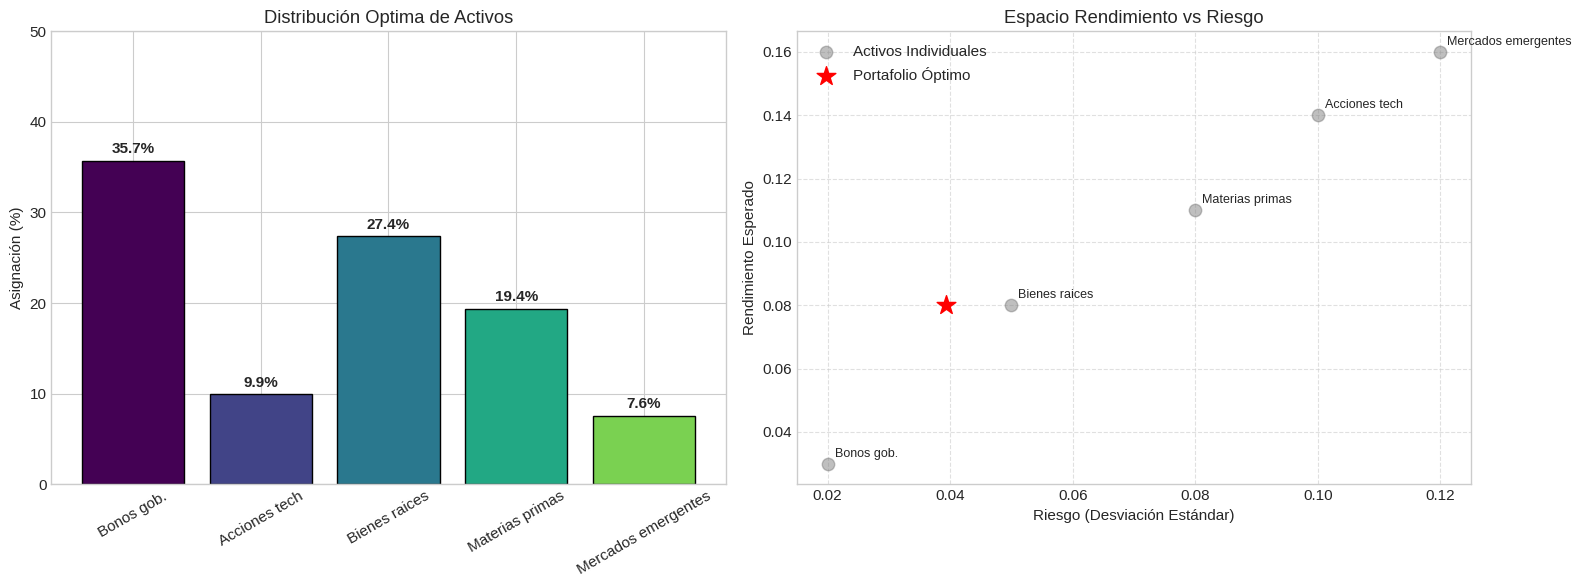

In [ ]:
import matplotlib.pyplot as plt

# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    # Cálculos necesarios
    desv_estandar_opt = np.sqrt(varianza_opt)
    rendimiento_opt = np.dot(w_opt, rendimientos_p2)

    # Riesgo y rendimiento de activos individuales para el Panel 2
    riesgos_ind = np.sqrt(np.diag(cov_p2))
    rendimientos_ind = rendimientos_p2

    # Crear figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: Asignación del Portafolio
    colores = plt.cm.viridis(np.linspace(0, 0.8, len(activos_p2)))
    bars = ax1.bar(activos_p2, w_opt * 100, color=colores, edgecolor='black')
    ax1.set_title("Distribución Optima de Activos")
    ax1.set_ylabel("Asignación (%)")
    ax1.set_ylim(0, 50)  # Límite superior un poco más del 40%
    ax1.tick_params(axis='x', rotation=30)

    # Añadir etiquetas de porcentaje sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%',
                 ha='center', va='bottom', fontweight='bold')

    # Panel 2: Rendimiento vs Riesgo
    # Activos individuales
    ax2.scatter(riesgos_ind, rendimientos_ind, color='gray', s=80, alpha=0.5, label='Activos Individuales')
    for i, txt in enumerate(activos_p2):
        ax2.annotate(txt, (riesgos_ind[i], rendimientos_ind[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)

    # Portafolio Óptimo
    ax2.scatter(desv_estandar_opt, rendimiento_opt, color='red', marker='*', s=200, label='Portafolio Óptimo')

    ax2.set_title("Espacio Rendimiento vs Riesgo")
    ax2.set_xlabel("Riesgo (Desviación Estándar)")
    ax2.set_ylabel("Rendimiento Esperado")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

**Variables de decision:**

$$x_i \in \{0, 1\} \quad \text{donde } x_i = 1 \text{ si se construye la torre } i, \text{ y } 0 \text{ en caso contrario.}$$

**Funcion objetivo:**

$$\min Z = 50x_1 + 80x_2 + 60x_3 + 70x_4 + 90x_5 + 40x_6 + 75x_7$$

**Restricciones:**

$$\begin{aligned}
& x_1 + x_6 \geq 1 && \text{(Zona 1)} \\
& x_1 + x_2 \geq 1 && \text{(Zona 2)} \\
& x_1 + x_2 + x_7 \geq 1 && \text{(Zona 3)} \\
& x_2 + x_3 \geq 1 && \text{(Zona 4)} \\
& x_2 + x_3 + x_4 \geq 1 && \text{(Zona 5)} \\
& x_3 + x_4 + x_7 \geq 1 && \text{(Zona 6)} \\
& x_4 + x_5 + x_7 \geq 1 && \text{(Zona 7)} \\
& x_4 + x_5 \geq 1 && \text{(Zona 8)} \\
& x_5 + x_6 \geq 1 && \text{(Zona 9)} \\
& x_5 + x_6 \geq 1 && \text{(Zona 10)}
\end{aligned}$$

### 3.2 Eleccion de optimizador

**Optimizador elegido:**

`scipy.optimize.milp`

**Justificacion (2-3 oraciones):**

Este es un problema de Programación Lineal Entera Mixta (MILP), específicamente del tipo "set covering", donde las variables deben ser obligatoriamente binarias (0 o 1). Se elige `scipy.optimize.milp` porque permite definir restricciones de integridad, asegurando que no se seleccionen fracciones de torres, algo que un optimizador lineal continuo no podría garantizar.

In [ ]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [ ]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    return np.dot(y, costos_torres_p3)


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool -- True si todas las zonas estan cubiertas
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    # Calculamos la cobertura por zona (vector de tamaño 10)
    # Sumamos las filas de la matriz de cobertura multiplicadas por la decisión y
    cobertura_por_zona = np.dot(y, cobertura_p3)

    zonas_cubiertas = np.where(cobertura_por_zona >= 1)[0].tolist()
    zonas_sin_cubrir = np.where(cobertura_por_zona == 0)[0].tolist()

    return {
        'factible': len(zonas_sin_cubrir) == 0,
        'zonas_cubiertas': zonas_cubiertas,
        'zonas_sin_cubrir': zonas_sin_cubrir
    }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """
    from scipy.optimize import milp, LinearConstraint, Bounds

    # Coeficientes de la función objetivo (costos)
    c = costos_torres_p3

    # Restricciones: Matriz de cobertura transpuesta para que sea (zonas x torres)
    # Cada zona debe estar cubierta por al menos 1 torre
    A = cobertura_p3.T
    constraints = LinearConstraint(A, lb=1, ub=np.inf)

    # Variables binarias (integrality=1)
    integrality = np.ones(n_torres_p3)

    # Límites: entre 0 y 1
    bounds = Bounds(0, 1)

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)

    if res.success:
        return res.x, res.fun
    else:
        return None, None

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


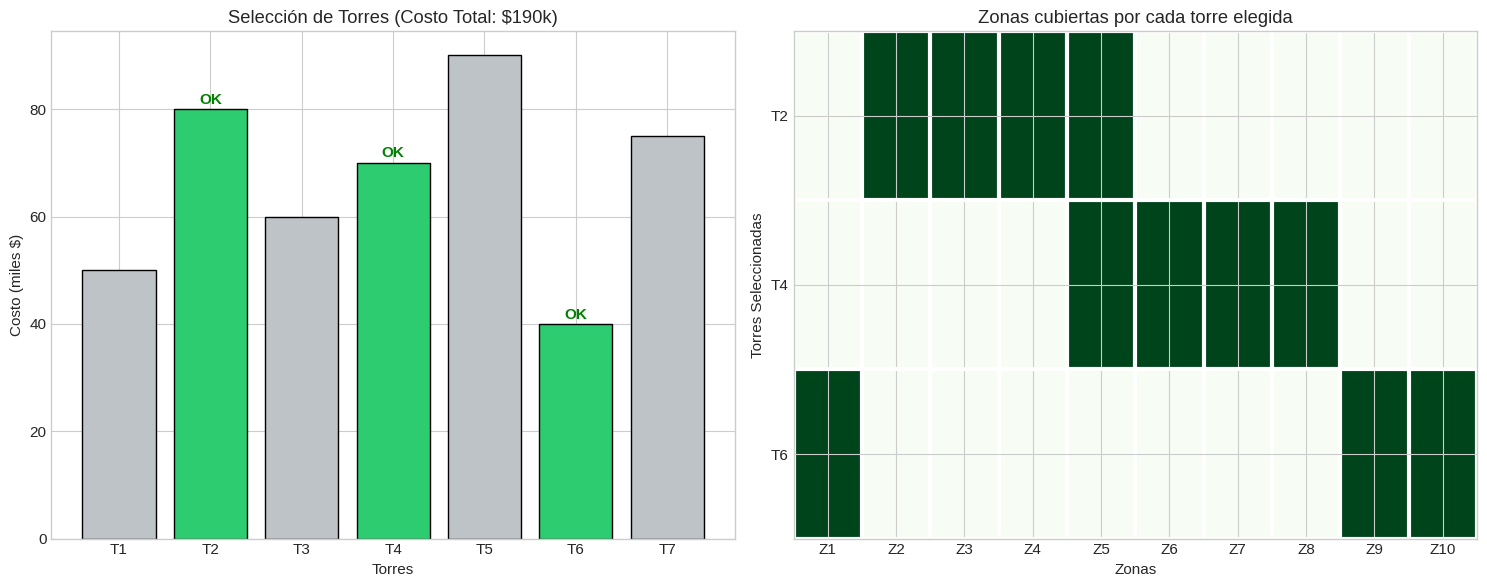

In [ ]:
import matplotlib.pyplot as plt

# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura.

    Debe mostrar:
    - Que torres se seleccionaron (con costos)
    - Que zonas cubre cada torre seleccionada

    Args:
        y_opt: np.array (7,)
        costo_opt: float
    """
    # Índices de las torres seleccionadas
    idx_seleccionadas = np.where(y_opt > 0.5)[0]
    nombres_sel = [nombres_torres_p3[i] for i in idx_seleccionadas]

    # Crear figura con dos paneles
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Panel 1: Torres seleccionadas y sus costos
    # Pintamos de verde las seleccionadas y de gris las que no
    colores = ['#2ecc71' if y > 0.5 else '#bdc3c7' for y in y_opt]
    ax1.bar(nombres_torres_p3, costos_torres_p3, color=colores, edgecolor='black')
    ax1.set_title(f"Selección de Torres (Costo Total: ${costo_opt:.0f}k)")
    ax1.set_ylabel("Costo (miles $)")
    ax1.set_xlabel("Torres")

    # Añadir etiquetas de texto sobre las barras seleccionadas
    for i, sel in enumerate(y_opt):
        if sel > 0.5:
            ax1.text(i, costos_torres_p3[i] + 1, 'OK', ha='center', fontweight='bold', color='green')

    # Panel 2: Matriz de cobertura de las torres seleccionadas
    # Filtramos la matriz de cobertura para mostrar solo las filas de las torres elegidas
    matriz_sel = cobertura_p3[idx_seleccionadas, :]

    im = ax2.imshow(matriz_sel, cmap='Greens', aspect='auto')

    ax2.set_title("Zonas cubiertas por cada torre elegida")
    ax2.set_xticks(np.arange(n_zonas_p3))
    ax2.set_xticklabels([f"Z{i+1}" for i in range(n_zonas_p3)])
    ax2.set_yticks(np.arange(len(idx_seleccionadas)))
    ax2.set_yticklabels(nombres_sel)
    ax2.set_xlabel("Zonas")
    ax2.set_ylabel("Torres Seleccionadas")

    # Añadir líneas de división para mejor legibilidad en el mapa de calor
    ax2.set_xticks(np.arange(-.5, n_zonas_p3, 1), minor=True)
    ax2.set_yticks(np.arange(-.5, len(idx_seleccionadas), 1), minor=True)
    ax2.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax2.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig('cobertura_torres_p3.png')


# Resolver y visualizar
y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

**Variables de decision:**

$$p = [a, b, c, d]^T \text{ (Vector de parámetros del sensor)}$$

**Funcion objetivo:**

$$\min Z = \sum_{i=1}^{20} (y(t_i) - y_{obs,i})^2$$
$$\min Z = \sum_{i=1}^{20} (a \cdot \sin(b \cdot t_i + c) + d \cdot e^{-0.1 \cdot t_i} - y_{obs,i})^2$$

**Restricciones (Cotas):**

$$\begin{aligned}
& 0 \leq a \leq 5 \\
& 0 \leq b \leq 10 \\
& 0 \leq c \leq 2\pi \\
& -3 \leq d \leq 3
\end{aligned}$$

### 4.2 Eleccion de optimizador

**Optimizador elegido:**

`scipy.optimize.differential_evolution`

**Justificacion (2-3 oraciones):**

Debido a que la función objetivo presenta múltiples mínimos locales por el término del seno, un optimizador basado en gradiente local (como 'BFGS' o 'L-BFGS-B') podría quedar atrapado fácilmente en una solución subóptima. Se elige **Evolución Diferencial** porque es un algoritmo de optimización global estocástico que explora mejor el espacio de búsqueda y es muy robusto para problemas no convexos con cotas definidas.

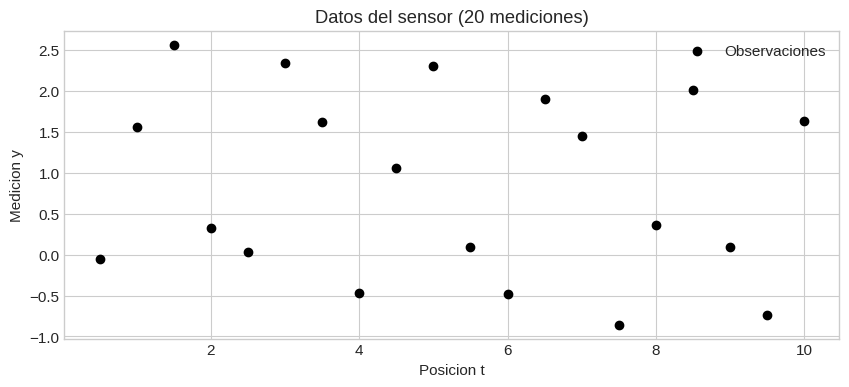

In [ ]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [ ]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.
    Se utiliza la Suma de Errores al Cuadrado (SSE).

    Args:
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        float -- error total (escalar)
    """
    y_pred = modelo_sensor(t_obs_p4, params)
    # Calculamos la suma de los residuos al cuadrado
    error_total = np.sum((y_pred - y_obs_p4)**2)
    return error_total


def resolver_p4():
    """Resuelve el problema de calibracion.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a, b, c, d]
        error_opt: float -- error minimo encontrado
    """
    from scipy.optimize import differential_evolution

    # Dado que el problema menciona múltiples mínimos locales,
    # differential_evolution es la opción más robusta para búsqueda global.
    res = differential_evolution(objetivo_p4, bounds_p4, seed=2026)

    if res.success:
        return res.x, res.fun
    else:
        return None, None

Solucion P4:
  a = 1.5089
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


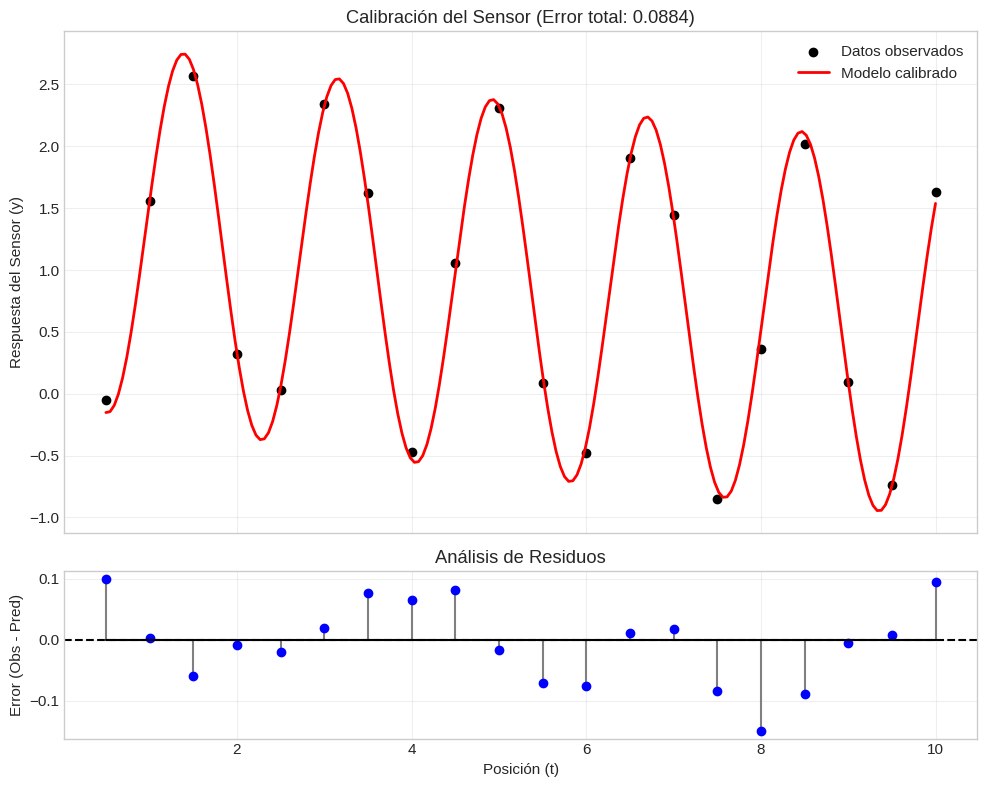

In [ ]:
import matplotlib.pyplot as plt

# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos.

    Debe mostrar:
    - Datos observados (puntos)
    - Curva del modelo con parametros encontrados (linea)
    - Residuos (errores punto a punto)

    Args:
        params_opt: np.array (4,)
        error_opt: float
    """
    # Generar puntos densos para mostrar una curva suave
    t_smooth = np.linspace(0.5, 10.0, 200)
    y_pred_smooth = modelo_sensor(t_smooth, params_opt)

    # Calcular predicciones en los puntos observados para los residuos
    y_pred_obs = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred_obs

    # Crear figura con dos paneles (GridSpec para que el de residuos sea más pequeño)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Panel 1: Ajuste del Modelo
    ax1.scatter(t_obs_p4, y_obs_p4, color="black", label="Datos observados", zorder=3)
    ax1.plot(t_smooth, y_pred_smooth, color="red", linewidth=2, label="Modelo calibrado", zorder=4)
    ax1.set_title(f"Calibración del Sensor (Error total: {error_opt:.4f})")
    ax1.set_ylabel("Respuesta del Sensor (y)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Panel 2: Residuos (Errores punto a punto)
    ax2.stem(t_obs_p4, residuos, basefmt="k-", linefmt="gray", markerfmt="bo")
    ax2.axhline(0, color="black", linestyle="--")
    ax2.set_title("Análisis de Residuos")
    ax2.set_ylabel("Error (Obs - Pred)")
    ax2.set_xlabel("Posición (t)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
if params_opt_p4 is not None:
    print(f"  a = {params_opt_p4[0]:.4f}")
    print(f"  b = {params_opt_p4[1]:.4f}")
    print(f"  c = {params_opt_p4[2]:.4f}")
    print(f"  d = {params_opt_p4[3]:.4f}")
    print(f"Error: {error_opt_p4:.6f}")

    plot_p4(params_opt_p4, error_opt_p4)
else:
    print("No se encontró una solución.")

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

**Variables de decision:**

* $y_i \in \{0, 1\}$: 1 si se abre el CD $i$, 0 en caso contrario (para $i = 1, \dots, 4$).
* $x_{ij} \geq 0$: Unidades enviadas desde el CD $i$ al cliente $j$ (para $j = 1, \dots, 6$).

**Funcion objetivo:**

$$\min Z = \sum_{i=1}^{4} \text{CostoFijo}_i \cdot y_i + \sum_{i=1}^{4} \sum_{j=1}^{6} \text{CostoEnvio}_{ij} \cdot x_{ij}$$

**Restricciones:**

1.  **Satisfacer Demanda:** $\sum_{i=1}^{4} x_{ij} = \text{Demanda}_j$ para cada cliente $j$.
2.  **Capacidad Máxima y Apertura:** $\sum_{j=1}^{6} x_{ij} \leq \text{Capacidad}_i \cdot y_i$ para cada CD $i$.
    *(Esta restricción asegura que si el CD no se abre ($y_i=0$), no se puede enviar nada).*
3.  **No negatividad e integridad:** $x_{ij} \geq 0$, $y_i \in \{0, 1\}$.

### 5.2 Eleccion de optimizador

**Optimizador elegido:**

`scipy.optimize.milp`

**Justificacion (2-3 oraciones):**

Este problema pertenece a la categoría de Programación Lineal Entera Mixta (MILP) debido a que combina variables continuas (flujos de mercancía) con variables binarias (decisión de apertura). El optimizador `milp` de SciPy es el adecuado ya que puede manejar simultáneamente restricciones de integridad para los centros de distribución y optimizar las variables continuas de transporte de manera exacta.

In [ ]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [ ]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Args:
        y: np.array (4,) -- 1 si el CD esta abierto, 0 si no
        X: np.array (4, 6) -- unidades enviadas de CD i a cliente j

    Returns:
        float -- costo total
    """
    costo_fijo = np.sum(y * costos_fijos_p5)
    costo_envio = np.sum(X * costos_envio_p5)
    return costo_fijo + costo_envio


def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones.

    Args:
        y: np.array (4,) -- apertura de CDs
        X: np.array (4, 6) -- envios

    Returns:
        dict con:
            'factible': bool
            'demanda_cumplida': np.array (6,) -- unidades recibidas por cada cliente
            'capacidad_usada': np.array (4,) -- capacidad usada por cada CD
    """
    # 1. Unidades recibidas por cada cliente (suma de columnas)
    demanda_cumplida = np.sum(X, axis=0)
    # 2. Unidades enviadas desde cada CD (suma de filas)
    capacidad_usada = np.sum(X, axis=1)

    # Verificaciones
    check_demanda = np.allclose(demanda_cumplida, demandas_p5, atol=1e-5)
    # Capacidad usada <= Capacidad total * y (si y=0, capacidad=0)
    check_capacidad = np.all(capacidad_usada <= (capacidades_p5 * y) + 1e-5)
    # No negatividad
    check_no_neg = np.all(X >= -1e-5)

    factible = check_demanda and check_capacidad and check_no_neg

    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada
    }


def resolver_p5():
    """Resuelve el problema de red de distribucion.

    Returns:
        y_opt: np.array (4,) -- 1 si el CD se abre, 0 si no
        X_opt: np.array (4, 6) -- envios optimos
        costo_opt: float -- costo total minimo
    """
    from scipy.optimize import milp, LinearConstraint, Bounds

    # Vector c: [y1, y2, y3, y4, x11, x12, ..., x46] (Total 4 + 24 = 28 variables)
    c = np.concatenate([costos_fijos_p5, costos_envio_p5.flatten()])

    A = []
    lb = []
    ub = []

    # 1. Restricciones de Demanda (Suma de envios para cada cliente j == demandas_p5[j])
    for j in range(n_clientes_p5):
        row = np.zeros(28)
        for i in range(n_cds_p5):
            row[4 + i * n_clientes_p5 + j] = 1
        A.append(row)
        lb.append(demandas_p5[j])
        ub.append(demandas_p5[j])

    # 2. Restricciones de Capacidad (Suma envios CD i <= Capacidad i * y_i)
    # Reescribimos como: (Suma x_ij) - (Capacidad i * y_i) <= 0
    for i in range(n_cds_p5):
        row = np.zeros(28)
        row[i] = -capacidades_p5[i] # Coeficiente para y_i
        for j in range(n_clientes_p5):
            row[4 + i * n_clientes_p5 + j] = 1 # Coeficientes para x_ij
        A.append(row)
        lb.append(-np.inf)
        ub.append(0)

    constraints = LinearConstraint(np.array(A), lb, ub)

    # Integridad: Primeras 4 binarias (1), siguientes 24 continuas (0)
    integrality = np.concatenate([np.ones(4), np.zeros(24)])

    # Límites: y en [0,1], x en [0, inf]
    b_low = np.concatenate([np.zeros(4), np.zeros(24)])
    b_up = np.concatenate([np.ones(4), np.full(24, np.inf)])
    bounds = Bounds(b_low, b_up)

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)

    if res.success:
        y_opt = res.x[:4]
        X_opt = res.x[4:].reshape(4, 6)
        return y_opt, X_opt, res.fun
    else:
        return None, None, None

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


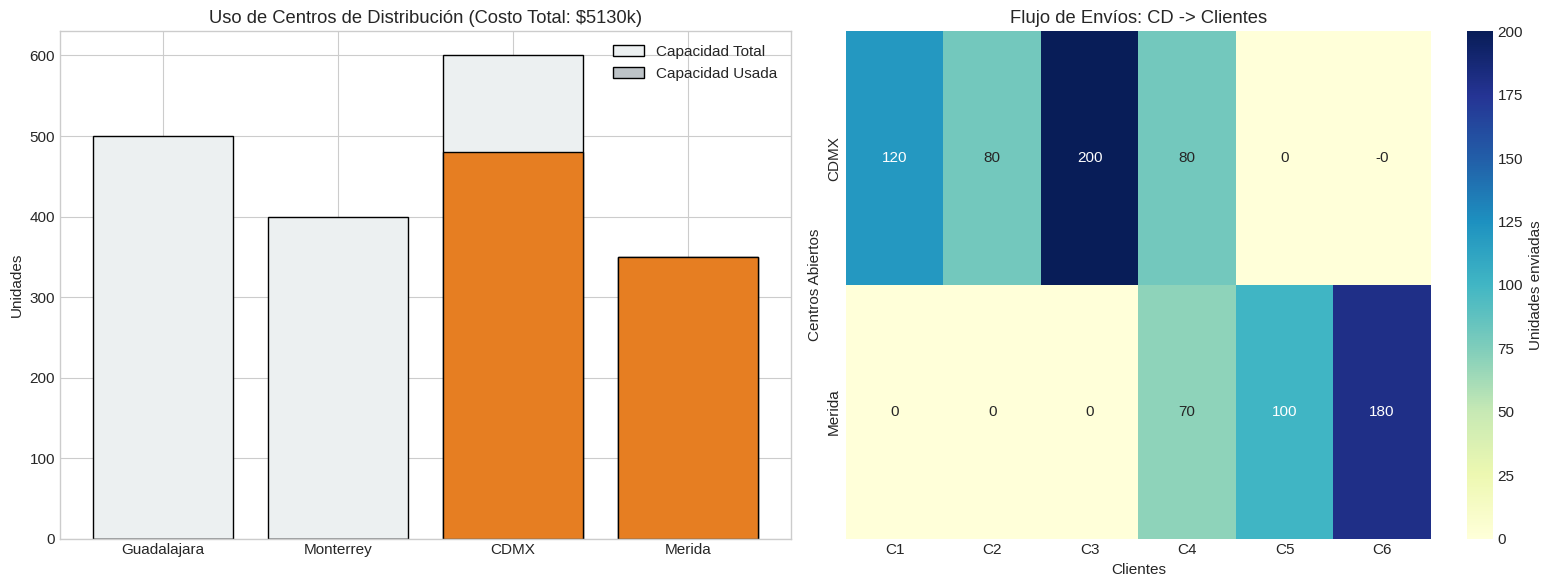

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion.

    Debe mostrar:
    - Que CDs estan abiertos (con capacidad usada vs disponible)
    - Flujo de envios: de cada CD a cada cliente

    Args:
        y_opt: np.array (4,)
        X_opt: np.array (4, 6)
        costo_opt: float
    """
    # 1. Preparar datos para capacidad
    capacidad_usada = np.sum(X_opt, axis=1)
    nombres_cds = ciudades_p5

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: Uso de Capacidad por CD
    # Mostramos la capacidad total en gris y la usada en color
    ax1.bar(nombres_cds, capacidades_p5, color='#ecf0f1', edgecolor='black', label='Capacidad Total')
    colores_cd = ['#e67e22' if y > 0.5 else '#bdc3c7' for y in y_opt]
    ax1.bar(nombres_cds, capacidad_usada, color=colores_cd, edgecolor='black', label='Capacidad Usada')

    ax1.set_title(f"Uso de Centros de Distribución (Costo Total: ${costo_opt:.0f}k)")
    ax1.set_ylabel("Unidades")
    ax1.legend()

    # Panel 2: Heatmap de envios (Flujo de Red)
    # Solo mostramos las filas de los CDs abiertos para no ensuciar la grafica
    idx_abiertos = np.where(y_opt > 0.5)[0]
    X_viz = X_opt[idx_abiertos, :]
    nombres_abiertos = [ciudades_p5[i] for i in idx_abiertos]

    sns.heatmap(X_viz, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax2,
                xticklabels=[f"C{j+1}" for j in range(n_clientes_p5)],
                yticklabels=nombres_abiertos, cbar_kws={'label': 'Unidades enviadas'})

    ax2.set_title("Flujo de Envíos: CD -> Clientes")
    ax2.set_xlabel("Clientes")
    ax2.set_ylabel("Centros Abiertos")

    plt.tight_layout()
    plt.show()

# Resolver y visualizar
y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

if y_opt_p5 is not None:
    print(f"Solucion P5:")
    for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
        if abierto > 0.5:
            cap_usada = X_opt_p5[i].sum()
            print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
            for j in range(n_clientes_p5):
                if X_opt_p5[i, j] > 0.1:
                    print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
    print(f"Costo total: ${costo_opt_p5:.0f}k")
    print(f"Factible: {info_p5['factible']}")

    plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)
else:
    print("No se pudo encontrar una solución óptima.")